# 📊 Deepfake Detection: Model Performance Comparison

This notebook provides a visualized comparison of all trained models. It relies on the `evaluation_results.json` generated by running:
```powershell
.venv\Scripts\python.exe src/evaluate.py
```

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
RESULTS_PATH = "../models/evaluation_results.json" if os.path.basename(os.getcwd()) == "notebooks" else "models/evaluation_results.json"

if not os.path.exists(RESULTS_PATH):
    print(f"❌ Results file not found at {RESULTS_PATH}.")
    print("Please run src/evaluate.py first to generate metrics.")
else:
    with open(RESULTS_PATH, "r") as f:
        results = json.load(f)
    
    df = pd.DataFrame(results).T
    print("✅ Results loaded successfully.")
    display(df)

✅ Results loaded successfully.


,Accuracy,Precision,Recall,F1_Score,AUC_ROC
CNN,0.9448,0.9503,0.9387,0.9445,0.9862
MesoNet,0.9509,0.9588,0.9424,0.9505,0.9897
EfficientNet,0.9594,0.9653,0.9531,0.9591,0.9926
Xception,0.5839,0.6451,0.3731,0.4728,0.6810
ResNet50,0.7518,0.8793,0.5837,0.7017,0.8953


## 1. Accuracy & F1-Score Comparison

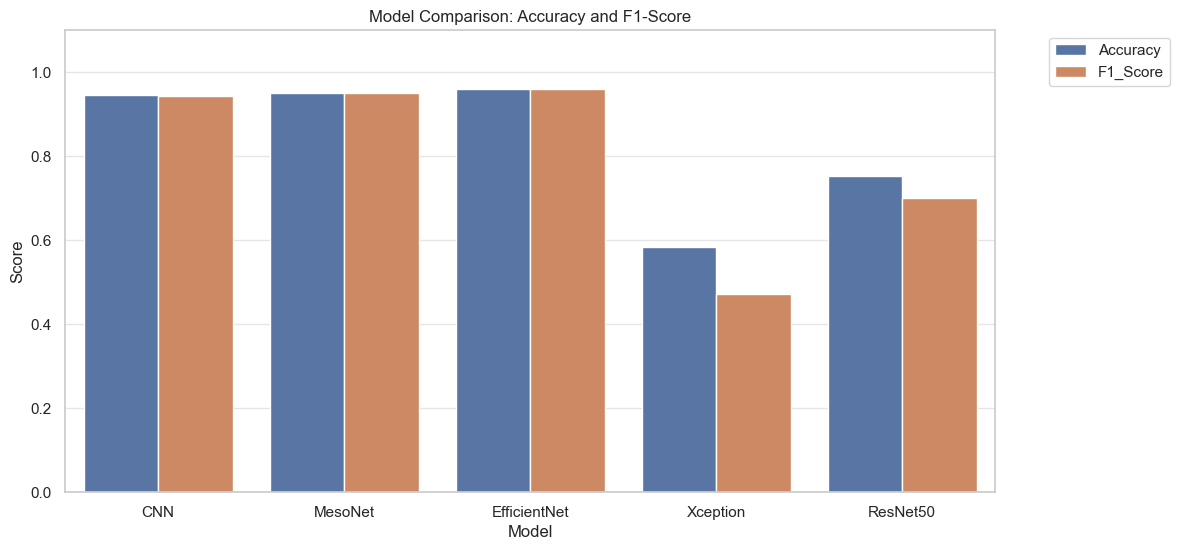

In [3]:
if "df" in locals():
    metrics_to_plot = ["Accuracy", "F1_Score"]
    df_melted = df[metrics_to_plot].reset_index().melt(id_vars="index", var_name="Metric", value_name="Score")
    df_melted.columns = ["Model", "Metric", "Score"]
    
    sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric")
    plt.title("Model Comparison: Accuracy and F1-Score")
    plt.ylim(0, 1.1)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

## 2. Precision & Recall Analysis

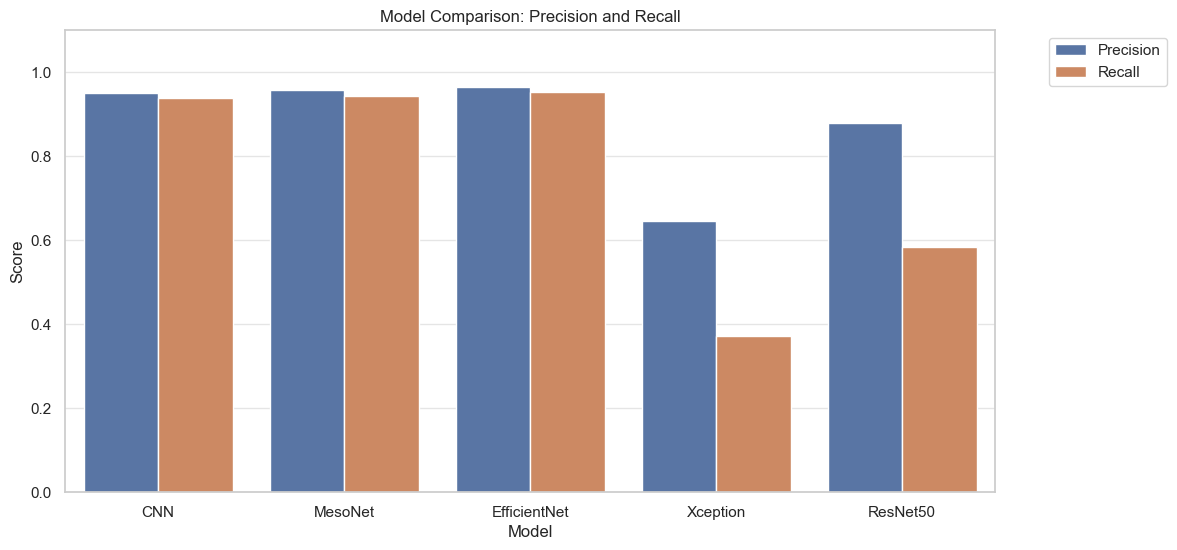

In [4]:
if "df" in locals():
    metrics_to_plot = ["Precision", "Recall"]
    df_melted = df[metrics_to_plot].reset_index().melt(id_vars="index", var_name="Metric", value_name="Score")
    df_melted.columns = ["Model", "Metric", "Score"]
    
    sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric")
    plt.title("Model Comparison: Precision and Recall")
    plt.ylim(0, 1.1)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

## 📊 Conclusion: The Best Model

Based on the charts above, you can now identify which model provides the most robust deepfake detection. 
- **Highest Accuracy:** Look for the highest bar in the first chart.
- **Fewest False Alarms:** Look for the highest **Precision**.
- **Missed Fewest Fakes:** Look for the highest **Recall** (Sensitivity).